# Environmental Kuznets Curve (EKC) Analysis
**Forest cover change (1990-2025) vs. Income level**

The EKC hypothesis: as countries develop economically, environmental degradation first increases then decreases (inverted-U). Here we proxy:
- **Economic development** = World Bank income group (LIC -> LMIC -> UMIC -> HIC)
- **Environmental quality** = Forest cover change (2025% minus 1990%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load & clean data

In [2]:
forest = pd.read_csv('../data_raw/Forest_share_1990_2025.csv')
forest.columns = ['Country', 'Forest_1990', 'Forest_2025']
forest['Forest_1990'] = pd.to_numeric(forest['Forest_1990'], errors='coerce')
forest['Forest_2025'] = pd.to_numeric(forest['Forest_2025'], errors='coerce')

aggregates = [
    'World', 'European Union (27)',
    'High-income countries', 'Low-income countries',
    'Lower-middle-income countries', 'Upper-middle-income countries',
    'England', 'Scotland', 'French Guiana'
]
forest = forest[~forest['Country'].isin(aggregates)].dropna(subset=['Forest_1990', 'Forest_2025'])
forest['Forest_change'] = forest['Forest_2025'] - forest['Forest_1990']

income_raw = pd.read_csv('../data_raw/2025_World_Bank_classification_by_Income.csv', skiprows=2)
income_raw.columns = ['Country', 'Code', 'Region', 'Income_group', 'Classification']
income = income_raw[['Country', 'Income_group']].dropna(subset=['Country', 'Income_group'])
income['Income_group'] = income['Income_group'].str.strip()
valid_groups = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income = income[income['Income_group'].isin(valid_groups)]

print(f'Forest data: {len(forest)} countries')
print(f'Income data: {len(income)} countries')

Forest data: 211 countries
Income data: 218 countries


## 2. Merge datasets

In [3]:
df = forest.merge(income, on='Country', how='inner')

name_map = {
    'Brunei': 'Brunei Darussalam',
    'Cape Verde': 'Cabo Verde',
    'Congo': 'Congo, Rep.',
    'Democratic Republic of Congo': 'Congo, Dem. Rep.',
    "Cote d'Ivoire": 'Côte d’Ivoire',
    'Curacao': 'Curaçao',
    'East Timor': 'Timor-Leste',
    'Egypt': 'Egypt, Arab Rep.',
    'Gambia': 'Gambia, The',
    'Bahamas': 'Bahamas, The',
    'Iran': 'Iran, Islamic Rep.',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Laos': 'Lao PDR',
    'Micronesia (country)': 'Micronesia, Fed. Sts.',
    'North Korea': "Korea, Dem. People's Rep.",
    'Russia': 'Russian Federation',
    'Saint Kitts and Nevis': 'St. Kitts and Nevis',
    'Saint Lucia': 'St. Lucia',
    'Saint Martin (French part)': 'St. Martin (French part)',
    'Saint Vincent and the Grenadines': 'St. Vincent and the Grenadines',
    'Sao Tome and Principe': 'São Tomé and Príncipe',
    'Slovakia': 'Slovak Republic',
    'South Korea': 'Korea, Rep.',
    'Syria': 'Syrian Arab Republic',
    'Turkey': 'Türkiye',
    'United States Virgin Islands': 'Virgin Islands (U.S.)',
    'Venezuela': 'Venezuela, RB',
    'Yemen': 'Yemen, Rep.',
}

already_matched = set(df['Country'])
unmatched = forest[~forest['Country'].isin(already_matched)].copy()
# Map to income-CSV names, merge, then restore original names
unmatched_mapped = unmatched.copy()
unmatched_mapped['Country'] = unmatched_mapped['Country'].replace(name_map)
extra = unmatched_mapped.merge(income, on='Country', how='inner')
reverse_map = {v: k for k, v in name_map.items()}
extra['Country'] = extra['Country'].replace(reverse_map)

df = pd.concat([df, extra], ignore_index=True)

order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
df['Income_group'] = pd.Categorical(df['Income_group'], categories=order, ordered=True)
df['Income_rank'] = df['Income_group'].cat.codes

print(f'Merged dataset: {len(df)} countries')
print(df['Income_group'].value_counts().reindex(order))


Merged dataset: 210 countries
Income_group
Low income             26
Lower middle income    50
Upper middle income    54
High income            80
Name: count, dtype: int64


## 3. Descriptive statistics by income group

In [4]:
summary = df.groupby('Income_group', observed=True).agg(
    n=('Forest_change', 'count'),
    mean_forest_1990=('Forest_1990', 'mean'),
    mean_forest_2025=('Forest_2025', 'mean'),
    mean_change=('Forest_change', 'mean'),
    median_change=('Forest_change', 'median'),
    pct_gainers=('Forest_change', lambda x: (x > 0).mean() * 100),
).round(2)
summary

,n,mean_forest_1990,mean_forest_2025,mean_change,median_change,pct_gainers
Income_group,,,,,,
Low income,26,29.85,24.60,-5.25,-2.68,19.23
Lower middle income,50,36.84,32.83,-4.01,-1.16,32.00
Upper middle income,54,38.17,37.76,-0.41,0.00,40.74
High income,80,31.64,32.95,1.30,0.71,58.75


## 4. Visualisations

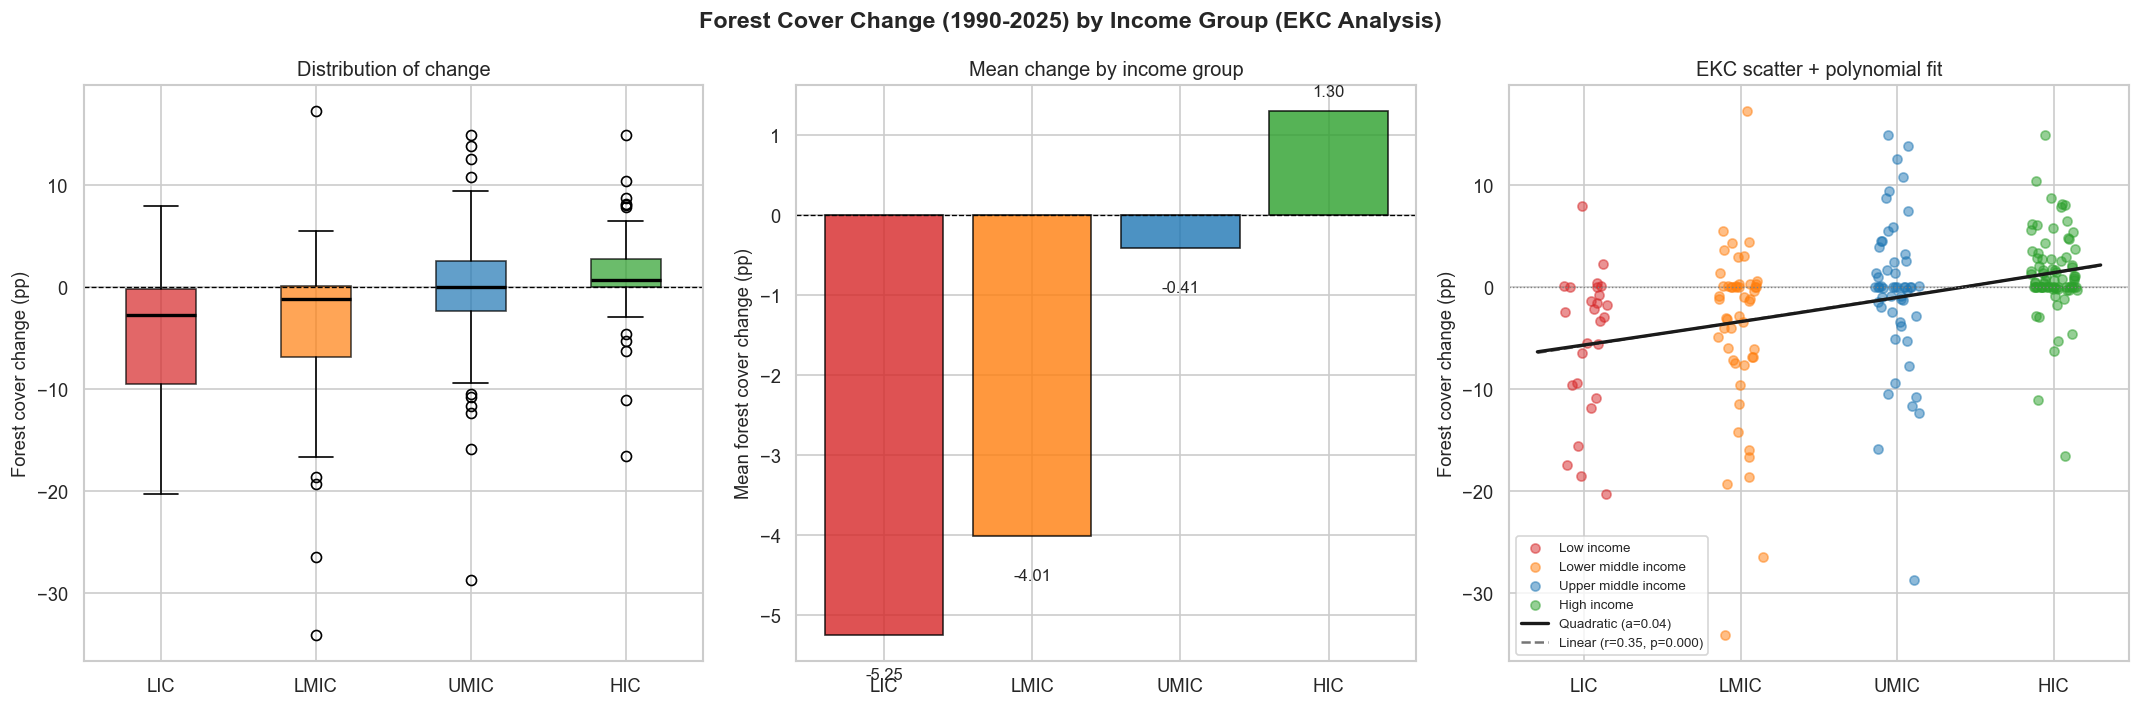

In [5]:
palette = {
    'Low income': '#d62728',
    'Lower middle income': '#ff7f0e',
    'Upper middle income': '#1f77b4',
    'High income': '#2ca02c',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Forest Cover Change (1990-2025) by Income Group (EKC Analysis)', fontsize=14, fontweight='bold')

# Box plot
ax1 = axes[0]
data_by_group = [df[df['Income_group'] == g]['Forest_change'].dropna() for g in order]
bp = ax1.boxplot(data_by_group, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
for patch, grp in zip(bp['boxes'], order):
    patch.set_facecolor(palette[grp])
    patch.set_alpha(0.7)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_xticks(range(1, 5))
ax1.set_xticklabels(['LIC', 'LMIC', 'UMIC', 'HIC'], fontsize=11)
ax1.set_ylabel('Forest cover change (pp)', fontsize=11)
ax1.set_title('Distribution of change')

# Mean change bar
ax2 = axes[1]
means = summary['mean_change']
bars = ax2.bar(range(4), means.values, color=[palette[g] for g in order], alpha=0.8, edgecolor='black')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xticks(range(4))
ax2.set_xticklabels(['LIC', 'LMIC', 'UMIC', 'HIC'], fontsize=11)
ax2.set_ylabel('Mean forest cover change (pp)', fontsize=11)
ax2.set_title('Mean change by income group')
for bar, val in zip(bars, means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + (0.15 if val >= 0 else -0.4),
             f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

# Scatter + polynomial
ax3 = axes[2]
rng = np.random.default_rng(42)
for grp in order:
    mask = df['Income_group'] == grp
    jitter = rng.uniform(-0.15, 0.15, mask.sum())
    ax3.scatter(df.loc[mask, 'Income_rank'] + jitter,
                df.loc[mask, 'Forest_change'],
                color=palette[grp], alpha=0.5, s=30, label=grp)

x = df['Income_rank'].values
y = df['Forest_change'].values
coeffs = np.polyfit(x, y, 2)
x_line = np.linspace(-0.3, 3.3, 200)
ax3.plot(x_line, np.polyval(coeffs, x_line), 'k-', linewidth=2,
         label=f'Quadratic (a={coeffs[0]:.2f})')
slope, intercept, r, p_val, _ = stats.linregress(x, y)
ax3.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5, alpha=0.6,
         label=f'Linear (r={r:.2f}, p={p_val:.3f})')
ax3.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['LIC', 'LMIC', 'UMIC', 'HIC'], fontsize=11)
ax3.set_ylabel('Forest cover change (pp)', fontsize=11)
ax3.set_title('EKC scatter + polynomial fit')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../ekc_forest_analysis.png', bbox_inches='tight')
plt.show()

## 5. Statistical tests

In [6]:
from scipy.stats import kruskal, mannwhitneyu

groups = [df[df['Income_group'] == g]['Forest_change'].dropna() for g in order]
kw_stat, kw_p = kruskal(*groups)
print(f'Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.4f}')
print('(p < 0.05 = income group significantly predicts forest change)\n')

pairs = [
    ('Low income', 'Lower middle income'),
    ('Lower middle income', 'Upper middle income'),
    ('Upper middle income', 'High income'),
    ('Low income', 'High income'),
]
print('Pairwise Mann-Whitney U (two-sided):')
for a, b in pairs:
    u, p = mannwhitneyu(
        df[df['Income_group'] == a]['Forest_change'].dropna(),
        df[df['Income_group'] == b]['Forest_change'].dropna(),
        alternative='two-sided'
    )
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {a:28s} vs {b:28s}  p={p:.4f}  {sig}')

Kruskal-Wallis H=35.41, p=0.0000
(p < 0.05 = income group significantly predicts forest change)

Pairwise Mann-Whitney U (two-sided):
  Low income                   vs Lower middle income           p=0.2711  ns
  Lower middle income          vs Upper middle income           p=0.0330  *
  Upper middle income          vs High income                   p=0.0314  *
  Low income                   vs High income                   p=0.0000  ***


## 6. EKC quadratic regression

In [7]:
import statsmodels.api as sm

df['rank2'] = df['Income_rank'] ** 2
X = sm.add_constant(df[['Income_rank', 'rank2']])
model = sm.OLS(df['Forest_change'], X).fit()
print(model.summary())

a, b = model.params['rank2'], model.params['Income_rank']
if a != 0:
    vertex = -b / (2 * a)
    print(f'\nQuadratic vertex at income_rank = {vertex:.2f}  (0=LIC, 1=LMIC, 2=UMIC, 3=HIC)')
    if 0 < vertex < 3 and a < 0:
        print('=> Inverted-U shape: CONSISTENT with EKC hypothesis')
    elif 0 < vertex < 3 and a > 0:
        print('=> U-shape: OPPOSITE of EKC')
    else:
        print('=> Vertex outside income range: no clear EKC turning point')

                            OLS Regression Results                            
Dep. Variable:          Forest_change   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     14.89
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           9.07e-07
Time:                        14:19:20   Log-Likelihood:                -693.81
No. Observations:                 210   AIC:                             1394.
Df Residuals:                     207   BIC:                             1404.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.6587      1.236     -4.577      

## 7. Top gainers & losers per income group

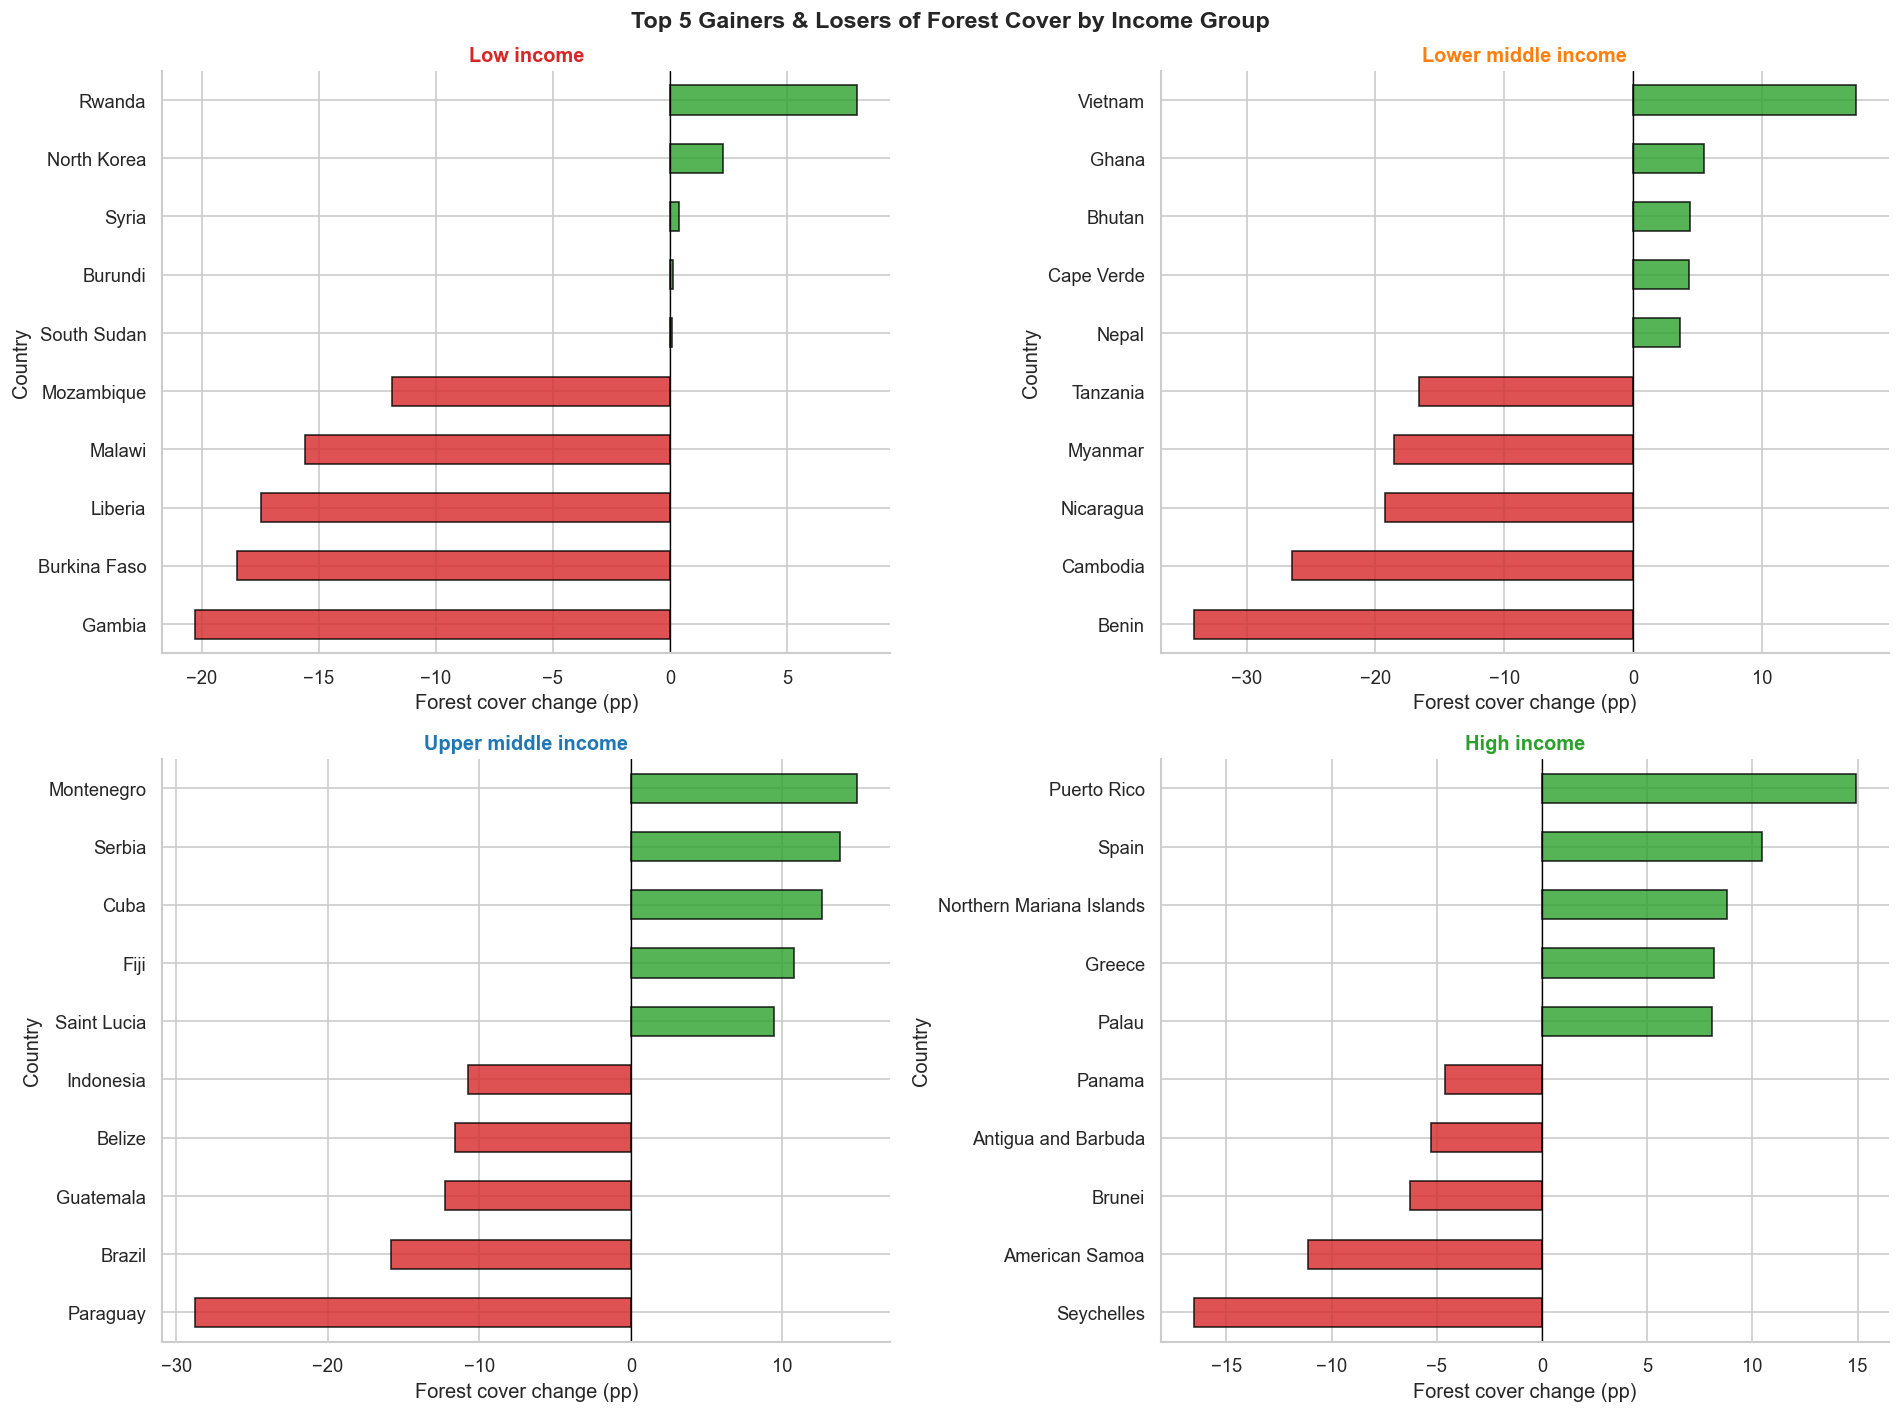

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 5 Gainers & Losers of Forest Cover by Income Group', fontsize=14, fontweight='bold')

for ax, grp in zip(axes.flat, order):
    sub = df[df['Income_group'] == grp].set_index('Country')['Forest_change'].dropna()
    combined = pd.concat([sub.nlargest(5), sub.nsmallest(5)]).sort_values()
    bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in combined]
    combined.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(grp, color=palette[grp], fontweight='bold')
    ax.set_xlabel('Forest cover change (pp)')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../ekc_gainers_losers.png', bbox_inches='tight')
plt.show()

## 8. Interpretation guide

| Finding | EKC implication |
|---|---|
| Quadratic `a < 0` + vertex in (0,3) | Inverted-U — **EKC supported** |
| Quadratic `a > 0` | U-shape — **EKC rejected** |
| Linear slope positive | Richer countries gain more forest |
| Kruskal-Wallis p < 0.05 | Income group meaningfully predicts forest change |

**Caveats:** Income groups are ordinal proxies (within-group variance is large). Forest cover is one environmental dimension — emissions or biodiversity may show a different pattern. This is cross-sectional, not longitudinal trajectory data.

---
# Part 2: Does Region Matter More Than GDP?
**Hypothesis:** Region and political context are stronger predictors of forest cover change than income group alone.

We compare variance explained (η²) by region vs. income group and build OLS models with each predictor separately and combined.

## 9. Add region to the dataset

In [9]:
# Re-use income_raw (loaded in cell 3) to get Region
income_full = income_raw[['Country', 'Income_group', 'Region']].dropna(subset=['Country', 'Region'])
income_full = income_full.copy()
income_full['Income_group'] = income_full['Income_group'].str.strip()

# Apply same name harmonisation as before
forest_mapped = forest.copy()
forest_mapped['Country_key'] = forest_mapped['Country'].replace(name_map)
df2 = forest_mapped.merge(
    income_full.rename(columns={'Country': 'Country_key'}),
    on='Country_key', how='inner'
).drop(columns='Country_key')

df2['Income_group'] = pd.Categorical(
    df2['Income_group'],
    categories=['Low income', 'Lower middle income', 'Upper middle income', 'High income'],
    ordered=True
)
df2['Income_rank'] = df2['Income_group'].cat.codes

region_labels = {
    'Sub-Saharan Africa':        'Africa',
    'East Asia & Pacific':       'E. Asia & Pacific',
    'Europe & Central Asia':     'Europe & C. Asia',
    'Latin America & Caribbean': 'Latin America',
    'Middle East & North Africa':'MENA',
    'North America':             'N. America',
    'South Asia':                'South Asia',
}
df2['Region_short'] = df2['Region'].map(region_labels)

print(f'Dataset with region: {len(df2)} countries')
print(df2['Region'].value_counts())

Dataset with region: 210 countries
Region
Europe & Central Asia         55
Sub-Saharan Africa            48
Latin America & Caribbean     42
East Asia & Pacific           35
Middle East & North Africa    19
South Asia                     8
North America                  3
Name: count, dtype: int64


## 10. Descriptive statistics by region

In [10]:
reg_summary = df2.groupby('Region_short').agg(
    n=('Forest_change', 'count'),
    mean_change=('Forest_change', 'mean'),
    median_change=('Forest_change', 'median'),
    std_change=('Forest_change', 'std'),
    pct_gainers=('Forest_change', lambda x: (x > 0).mean() * 100),
).round(2).sort_values('mean_change')
reg_summary

,n,mean_change,median_change,std_change,pct_gainers
Region_short,,,,,
Africa,48,-5.91,-3.34,7.73,18.75
Latin America,42,-2.43,-0.67,8.10,26.19
E. Asia & Pacific,35,-0.93,-0.11,8.00,37.14
MENA,19,0.28,0.00,0.87,42.11
N. America,3,0.54,0.71,0.48,66.67
South Asia,8,0.72,0.00,2.78,37.50
Europe & C. Asia,55,2.75,1.67,3.35,80.00


## 11. Region vs Income visualisations

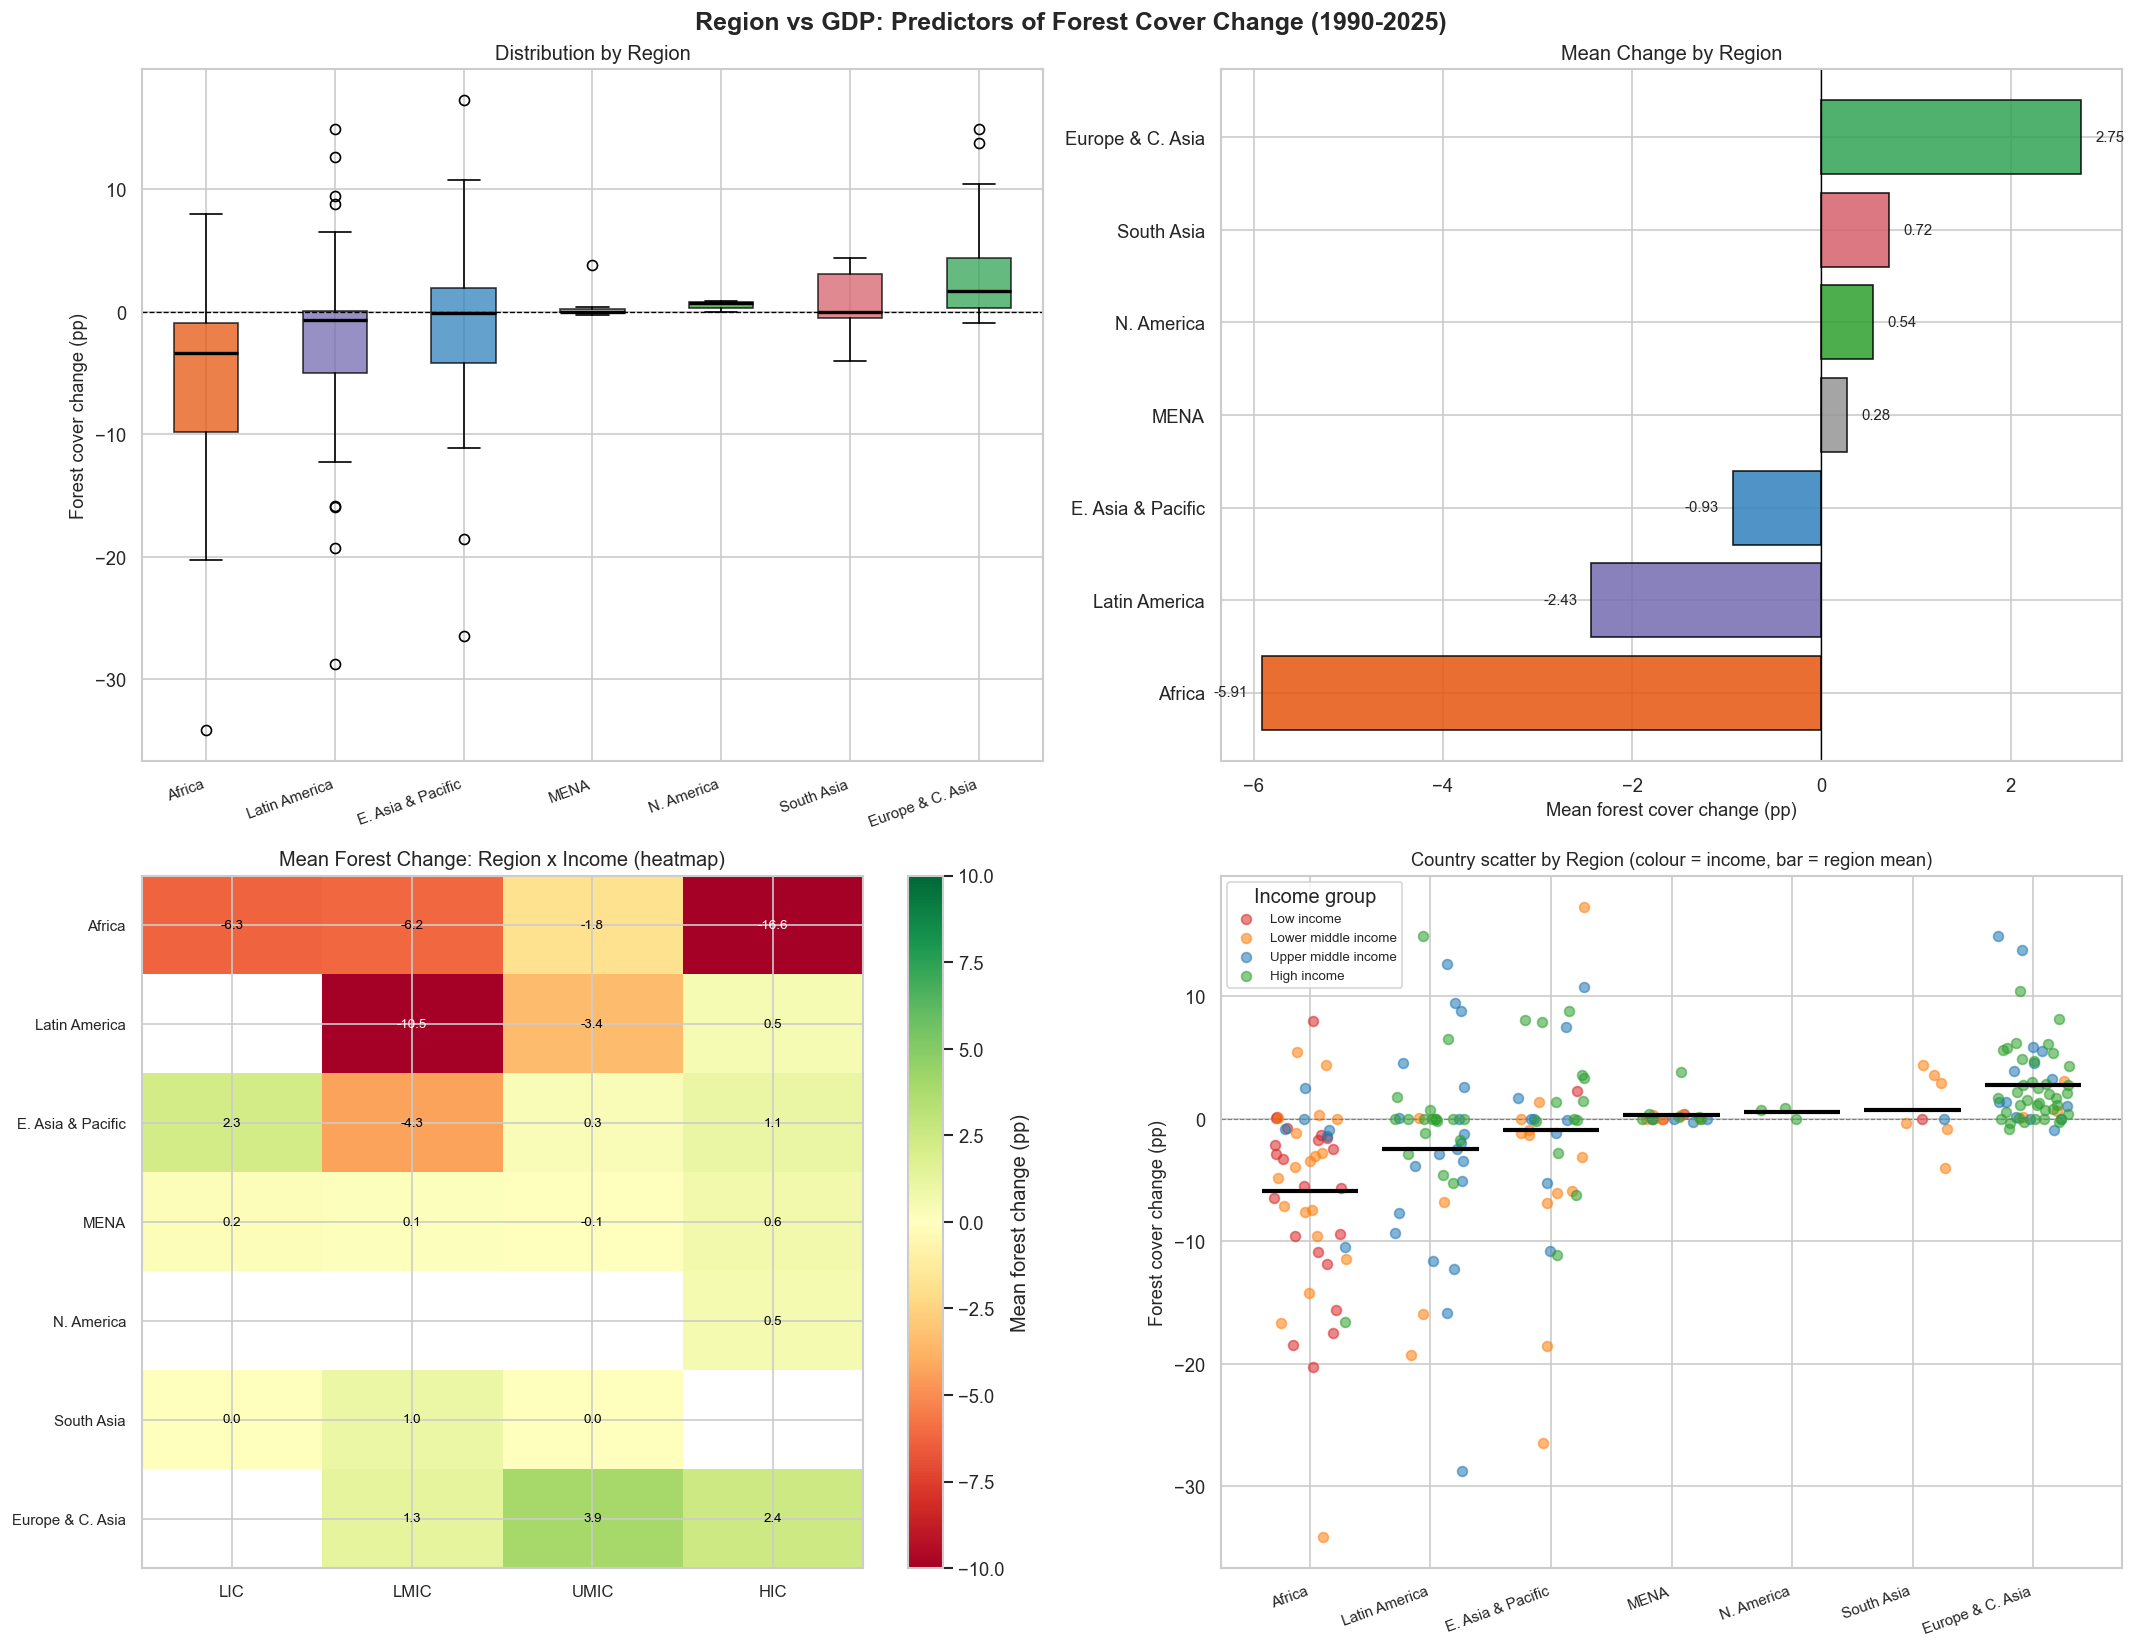

In [11]:
region_order = reg_summary.index.tolist()  # sorted by mean change
income_order  = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_colors = {'Low income':'#d62728', 'Lower middle income':'#ff7f0e',
                 'Upper middle income':'#1f77b4', 'High income':'#2ca02c'}
region_palette = {
    'Africa':           '#e6550d',
    'E. Asia & Pacific':'#3182bd',
    'Europe & C. Asia': '#31a354',
    'Latin America':    '#756bb1',
    'MENA':             '#969696',
    'N. America':       '#2ca02c',
    'South Asia':       '#d6616b',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Region vs GDP: Predictors of Forest Cover Change (1990-2025)',
             fontsize=15, fontweight='bold')

# --- Box plot by region ---
ax = axes[0, 0]
data_reg = [df2[df2['Region_short'] == r]['Forest_change'].dropna() for r in region_order]
bp = ax.boxplot(data_reg, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, r in zip(bp['boxes'], region_order):
    patch.set_facecolor(region_palette[r])
    patch.set_alpha(0.75)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xticks(range(1, len(region_order) + 1))
ax.set_xticklabels(region_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Distribution by Region', fontsize=12)

# --- Mean change by region (horizontal bar) ---
ax = axes[0, 1]
region_means = df2.groupby('Region_short')['Forest_change'].mean().reindex(region_order)
colors_r = [region_palette[r] for r in region_order]
bars = ax.barh(region_order, region_means.values, color=colors_r, alpha=0.85, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, region_means.values):
    ax.text(val + (0.15 if val >= 0 else -0.15),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Mean forest cover change (pp)', fontsize=11)
ax.set_title('Mean Change by Region', fontsize=12)

# --- Heatmap region x income group ---
ax = axes[1, 0]
pivot = df2.groupby(['Region_short', 'Income_group'], observed=True)['Forest_change'] \
           .mean().unstack().reindex(region_order)
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(['LIC', 'LMIC', 'UMIC', 'HIC'], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Mean forest change (pp)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < 7 else 'white')
ax.set_title('Mean Forest Change: Region x Income (heatmap)', fontsize=12)

# --- Strip plot: region on x, coloured by income ---
ax = axes[1, 1]
rng = np.random.default_rng(0)
for ig in income_order:
    sub = df2[df2['Income_group'] == ig]
    x_pos = [region_order.index(r) + rng.uniform(-0.3, 0.3)
             for r in sub['Region_short']]
    ax.scatter(x_pos, sub['Forest_change'],
               color=income_colors[ig], alpha=0.55, s=35, label=ig)
for xi, r in enumerate(region_order):
    mean_val = df2[df2['Region_short'] == r]['Forest_change'].mean()
    ax.hlines(mean_val, xi - 0.4, xi + 0.4, colors='black', linewidth=2.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Country scatter by Region (colour = income, bar = region mean)', fontsize=11)
ax.legend(title='Income group', fontsize=8)

plt.tight_layout()
plt.savefig('../region_vs_gdp.png', bbox_inches='tight')
plt.show()

## 12. Effect size: η² and OLS R² comparison

In [12]:
from scipy.stats import f_oneway
import statsmodels.formula.api as smf

def eta_squared(groups_data):
    all_vals = np.concatenate(groups_data)
    grand_mean = all_vals.mean()
    ss_total   = ((all_vals - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_data)
    return ss_between / ss_total

income_groups = [df2[df2['Income_group'] == g]['Forest_change'].dropna().values
                 for g in income_order]
region_groups = [df2[df2['Region_short'] == r]['Forest_change'].dropna().values
                 for r in region_order]

eta2_income = eta_squared(income_groups)
eta2_region = eta_squared(region_groups)
f_inc, p_inc = f_oneway(*income_groups)
f_reg, p_reg = f_oneway(*region_groups)

df2['Income_str'] = df2['Income_group'].astype(str)
m_income = smf.ols('Forest_change ~ C(Income_str)',   data=df2).fit()
m_region = smf.ols('Forest_change ~ C(Region_short)', data=df2).fit()
m_both   = smf.ols('Forest_change ~ C(Region_short) + C(Income_str)', data=df2).fit()

print('One-way ANOVA:')
print(f'  Income group : F={f_inc:.2f}  p={p_inc:.4f}  eta2={eta2_income:.3f}  ({eta2_income*100:.1f}% variance)')
print(f'  Region       : F={f_reg:.2f}  p={p_reg:.4f}  eta2={eta2_region:.3f}  ({eta2_region*100:.1f}% variance)')
print()
print('OLS R2:')
print(f'  Income only   : R2={m_income.rsquared:.3f}  AIC={m_income.aic:.1f}')
print(f'  Region only   : R2={m_region.rsquared:.3f}  AIC={m_region.aic:.1f}')
print(f'  Region+Income : R2={m_both.rsquared:.3f}  AIC={m_both.aic:.1f}')
print()
if eta2_region > eta2_income:
    ratio = eta2_region / eta2_income
    print(f'=> Region explains {ratio:.1f}x more variance than income group')
    print('=> Hypothesis SUPPORTED: region is a stronger predictor than GDP')
else:
    ratio = eta2_income / eta2_region
    print(f'=> Income group explains {ratio:.1f}x more variance than region')
    print('=> Hypothesis REJECTED: GDP is the stronger predictor')

One-way ANOVA:
  Income group : F=10.28  p=0.0000  eta2=0.130  (13.0% variance)
  Region       : F=8.38  p=0.0000  eta2=0.199  (19.9% variance)

OLS R2:
  Income only   : R2=0.130  AIC=1394.6
  Region only   : R2=0.199  AIC=1383.4
  Region+Income : R2=0.229  AIC=1381.3

=> Region explains 1.5x more variance than income group
=> Hypothesis SUPPORTED: region is a stronger predictor than GDP


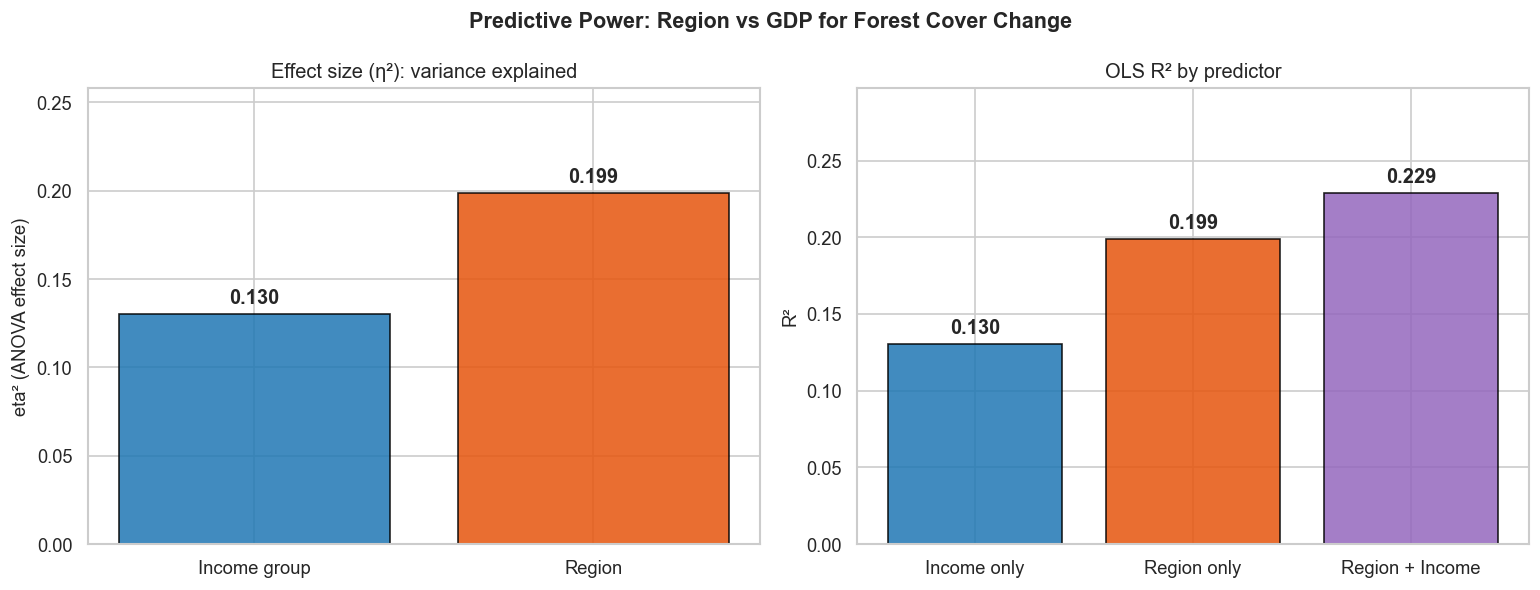

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predictive Power: Region vs GDP for Forest Cover Change',
             fontsize=13, fontweight='bold')

# eta2 bar
ax = axes[0]
vals = [eta2_income, eta2_region]
bars = ax.bar(['Income group', 'Region'], vals,
              color=['#1f77b4', '#e6550d'], alpha=0.85, edgecolor='black')
ax.set_ylabel('eta² (ANOVA effect size)', fontsize=11)
ax.set_title('Effect size (η²): variance explained', fontsize=12)
ax.set_ylim(0, max(vals) * 1.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(vals) * 0.03,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# R2 bar
ax = axes[1]
r2_vals  = [m_income.rsquared, m_region.rsquared, m_both.rsquared]
r2_labels = ['Income only', 'Region only', 'Region + Income']
r2_colors = ['#1f77b4', '#e6550d', '#9467bd']
bars = ax.bar(r2_labels, r2_vals, color=r2_colors, alpha=0.85, edgecolor='black')
ax.set_ylabel('R²', fontsize=11)
ax.set_title('OLS R² by predictor', fontsize=12)
ax.set_ylim(0, max(r2_vals) * 1.3)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(r2_vals) * 0.03,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../region_vs_gdp_r2.png', bbox_inches='tight')
plt.show()

## 13. Non-parametric check: Kruskal-Wallis H comparison

In [14]:
from scipy.stats import kruskal

kw_stat_r, kw_p_r = kruskal(*region_groups)
kw_stat_i, kw_p_i = kruskal(*income_groups)

print(f'Kruskal-Wallis (region) : H={kw_stat_r:.2f}  p={kw_p_r:.4f}')
print(f'Kruskal-Wallis (income) : H={kw_stat_i:.2f}  p={kw_p_i:.4f}')
print(f'Region H / Income H = {kw_stat_r / kw_stat_i:.2f}  (>1 means region separates groups more)')

Kruskal-Wallis (region) : H=63.56  p=0.0000
Kruskal-Wallis (income) : H=35.41  p=0.0000
Region H / Income H = 1.79  (>1 means region separates groups more)


## 14. Conclusion

| Metric | Income group | Region | Stronger predictor |
|---|---|---|---|
| ANOVA η² | *see output* | *see output* | higher value wins |
| OLS R² | *see output* | *see output* | higher value wins |
| Kruskal-Wallis H | *see output* | *see output* | higher H wins |

**How to read the result:**
- If Region η² > Income η² across all three metrics → **hypothesis supported** (geography/institutions dominate).
- The combined model R² shows how much additional variance income explains *on top of* region.
- The heatmap reveals whether the income effect is *consistent* across regions or highly region-specific.

**Caveat:** Income *rank* is an ordinal proxy. Adding actual GNI per capita would allow a continuous EKC regression.

---
# Part 3: Where Are the Biggest Exceptions?
**Hypothesis:** Policy plays a role independent of GDP — some wealthy countries keep deforesting while some poor countries successfully reforest, driven by restoration commitments, governance, or population pressure.

We use **real GDP per capita (2023 USD)** from the World Bank GDP dataset as a continuous wealth proxy instead of the ordinal income categories used above.

## 15. Load GDP per capita & build combined dataset

In [15]:
gdp_raw = pd.read_csv('../data_raw/1960-2024_GDP_USD.csv', skiprows=4)
gdp_raw.columns = [str(c).strip() for c in gdp_raw.columns]
gdp_raw = gdp_raw[['Country Code', '1990', '2000', '2010', '2023']].copy()
gdp_raw.columns = ['Code', 'GDP_1990', 'GDP_2000', 'GDP_2010', 'GDP_2023']
for col in ['GDP_1990', 'GDP_2000', 'GDP_2010', 'GDP_2023']:
    gdp_raw[col] = pd.to_numeric(gdp_raw[col], errors='coerce')

# income_raw already loaded in cell 3; merge GDP via country code
income_coded = income_raw[['Country', 'Code', 'Income_group', 'Region']].dropna(subset=['Country']).copy()
income_coded['Income_group'] = income_coded['Income_group'].str.strip()
income_gdp = income_coded.merge(gdp_raw, on='Code', how='left')

# Apply same name harmonisation as Parts 1-2
forest_mapped2 = forest.copy()
forest_mapped2['Country_key'] = forest_mapped2['Country'].replace(name_map)
df3 = forest_mapped2.merge(
    income_gdp.rename(columns={'Country': 'Country_key'}),
    on='Country_key', how='inner'
).drop(columns='Country_key')

valid_groups = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
df3 = df3[df3['Income_group'].isin(valid_groups)].copy()
df3['Income_group'] = pd.Categorical(df3['Income_group'], categories=valid_groups, ordered=True)
df3['Income_rank'] = df3['Income_group'].cat.codes

region_labels = {
    'Sub-Saharan Africa': 'Africa', 'East Asia & Pacific': 'E. Asia & Pacific',
    'Europe & Central Asia': 'Europe & C. Asia', 'Latin America & Caribbean': 'Latin America',
    'Middle East & North Africa': 'MENA', 'North America': 'N. America', 'South Asia': 'South Asia',
}
df3['Region_short'] = df3['Region'].map(region_labels)

print(f'Countries total: {len(df3)}')
print(f'Countries with GDP_2023: {df3["GDP_2023"].notna().sum()}')
df3[['Country', 'Income_group', 'GDP_2023', 'Forest_change']].head(5)

Countries total: 210
Countries with GDP_2023: 197


,Country,Income_group,GDP_2023,Forest_change
0,Afghanistan,Low income,413.757895,0.00
1,Albania,Upper middle income,9730.869219,5.55
2,Algeria,Upper middle income,5370.477235,-0.01
3,American Samoa,High income,NaN,-11.10
4,Andorra,High income,46812.426101,1.13


## 16. Identify exceptions via regression residuals

In [16]:
# Fit log-linear baseline: expected forest change given log(GDP per capita)
mask_gdp = df3['GDP_2023'].notna()
log_gdp  = np.log1p(df3.loc[mask_gdp, 'GDP_2023'])
slope, intercept = np.polyfit(log_gdp, df3.loc[mask_gdp, 'Forest_change'], 1)

df3['Log_GDP_2023'] = np.log1p(df3['GDP_2023'])
df3['Expected_change'] = slope * df3['Log_GDP_2023'] + intercept
df3['Residual'] = df3['Forest_change'] - df3['Expected_change']

res_std = df3['Residual'].std()
print(f'Baseline: forest_change = {slope:.2f} * log(GDP) + {intercept:.2f}')
print(f'Residual std = {res_std:.2f} pp')
print()

# Tag exceptions: > +1 SD above trend = positive exception, < -1 SD = negative exception
df3['Exception'] = 'On trend'
df3.loc[df3['Residual'] >  res_std, 'Exception'] = 'Positive exception'
df3.loc[df3['Residual'] < -res_std, 'Exception'] = 'Negative exception'

print('Exception counts:')
print(df3['Exception'].value_counts())

Baseline: forest_change = 1.93 * log(GDP) + -18.84
Residual std = 6.52 pp

Exception counts:
Exception
On trend              168
Positive exception     21
Negative exception     21
Name: count, dtype: int64


In [17]:
# Hardcoded policy flags and population density for key exception countries
# Sources: Bonn Challenge, AFR100, national forestry commitments
restoration_commitment = {
    # Positive exceptions with known commitments
    'Vietnam': True,   # National Reforestation Programme (PAR 661), 5M ha target
    'Rwanda': True,    # AFR100 signatory, Green Growth Strategy
    'Ghana': True,     # AFR100, Bonn Challenge, 2M ha commitment
    'India': True,     # Bonn Challenge 21M ha, National Afforestation Programme
    'Nepal': True,     # Community forestry programme since 1978, Bonn Challenge
    'Bhutan': True,    # Constitutional mandate 60% forest cover
    'Cape Verde': True, # National reforestation plan
    'China': True,     # Three-North Shelter Forest, Grain for Green, 70M ha
    'Cuba': True,      # National reforestation programme
    'South Korea': True, # Saemaul Undong forest restoration in 1970s-80s
    'Costa Rica': True, # Payments for Ecosystem Services (PES), forest law
    'El Salvador': True, # National reforestation plan
    'Uruguay': True,   # Forestry Law 1987, plantation incentives
    'Chile': True,     # DL 701 forestry incentives
    'Ethiopia': True,  # Green Legacy Initiative, 20B trees
    'Kenya': True,     # AFR100, national tree planting campaigns
    'Rwanda': True,
    'Uganda': False,   # Large deforester despite LIC
    # Negative exceptions
    'Paraguay': False,  # Weak enforcement of Zero Deforestation Law until 2012
    'Brazil': False,    # Rollback of Amazon protections 2019-2022
    'Indonesia': False, # Palm oil expansion, weak concession enforcement
    'Belize': False,    # Logging concessions, agricultural expansion
    'Guatemala': False, # Drug trafficking, weak enforcement
    'Ecuador': False,   # Oil extraction, agricultural frontier
    'Colombia': False,  # Post-FARC agricultural expansion
    'Malaysia': False,  # Palm oil, weak logging controls
    'Brunei': True,     # Protected areas programme (anomaly)
    'Seychelles': False, # Tourism-driven land conversion
    'American Samoa': False, # Urban expansion
}

# Population density (people per km², approximate 2023 values)
pop_density = {
    'Vietnam': 314, 'Rwanda': 525, 'Ghana': 137, 'India': 464,
    'Nepal': 206, 'Bhutan': 21, 'Cape Verde': 140, 'Bangladesh': 1265,
    'Burundi': 459, 'Afghanistan': 56, 'Ethiopia': 126, 'Kenya': 101,
    'Uganda': 248, 'China': 153, 'South Korea': 527, 'Cuba': 110,
    'Costa Rica': 103, 'Chile': 26, 'Uruguay': 20, 'El Salvador': 320,
    'Paraguay': 18, 'Brazil': 25, 'Indonesia': 151, 'Guatemala': 175,
    'Ecuador': 70, 'Colombia': 47, 'Malaysia': 100, 'Belize': 17,
    'Brunei': 84, 'Seychelles': 215, 'American Samoa': 280,
    'Panama': 57, 'Peru': 26, 'Equatorial Guinea': 48, 'Myanmar': 82,
    'Honduras': 92, 'Bolivia': 11, 'Nicaragua': 55, 'Tanzania': 73,
    'Cameroon': 59, 'Zambia': 26, 'Mozambique': 40, 'Madagascar': 48,
}

df3['Policy_commitment'] = df3['Country'].map(restoration_commitment)
df3['Pop_density']       = df3['Country'].map(pop_density)

print('Policy flags assigned:', df3['Policy_commitment'].notna().sum())
print('Pop density assigned:', df3['Pop_density'].notna().sum())

Policy flags assigned: 28
Pop density assigned: 43


## 17. Exception tables

In [18]:
cols = ['Country', 'Region_short', 'Income_group', 'GDP_2023', 'Forest_1990', 'Forest_2025', 'Forest_change', 'Residual']

print('=== WEALTHY DEFORESTERS (UMIC/HIC, residual < -1 SD) ===')
wealthy_defor = df3[
    (df3['Income_rank'] >= 2) & (df3['Exception'] == 'Negative exception')
].sort_values('Residual')[cols].round(2)
display(wealthy_defor)

print('\n=== POOR REFORESTERS (LIC/LMIC, residual > +1 SD) ===')
poor_refor = df3[
    (df3['Income_rank'] <= 1) & (df3['Exception'] == 'Positive exception')
].sort_values('Residual', ascending=False)[cols].round(2)
display(poor_refor)

=== WEALTHY DEFORESTERS (UMIC/HIC, residual < -1 SD) ===


,Country,Region_short,Income_group,GDP_2023,Forest_1990,Forest_2025,Forest_change,Residual
147,Paraguay,Latin America,Upper middle income,6299.99,64.85,36.10,-28.75,-26.84
167,Seychelles,Africa,High income,18262.71,74.20,57.65,-16.55,-16.70
26,Brazil,Latin America,Upper middle income,10377.59,73.99,58.16,-15.83,-14.88
79,Guatemala,Latin America,Upper middle income,5758.33,45.28,32.99,-12.29,-10.20
19,Belize,Latin America,Upper middle income,7424.76,69.26,57.65,-11.61,-10.02
60,Equatorial Guinea,Africa,Upper middle income,6677.79,96.23,85.80,-10.43,-8.63
88,Indonesia,E. Asia & Pacific,Upper middle income,4876.31,61.47,50.71,-10.76,-8.35
57,Ecuador,Latin America,Upper middle income,6737.85,58.92,49.57,-9.35,-7.57
28,Brunei,E. Asia & Pacific,High income,32890.55,78.37,72.11,-6.26,-7.55



=== POOR REFORESTERS (LIC/LMIC, residual > +1 SD) ===


,Country,Region_short,Income_group,GDP_2023,Forest_1990,Forest_2025,Forest_change,Residual
206,Vietnam,E. Asia & Pacific,Lower middle income,4323.35,29.91,47.19,17.28,19.92
156,Rwanda,Africa,Low income,1027.03,17.71,25.72,8.01,13.43
74,Ghana,Africa,Lower middle income,2383.90,25.52,31.01,5.49,9.28
131,Nepal,South Asia,Lower middle income,1382.33,40.10,43.71,3.61,8.45
31,Burundi,Africa,Low income,250.63,10.77,10.89,0.12,8.26
22,Bhutan,South Asia,Lower middle income,3831.33,65.72,70.13,4.41,7.28
0,Afghanistan,South Asia,Low income,413.76,1.85,1.85,0.00,7.18
35,Cape Verde,Africa,Lower middle income,4794.90,8.31,12.67,4.36,6.80
87,India,South Asia,Lower middle income,2530.12,21.50,24.46,2.96,6.64


## 18. Visualisations

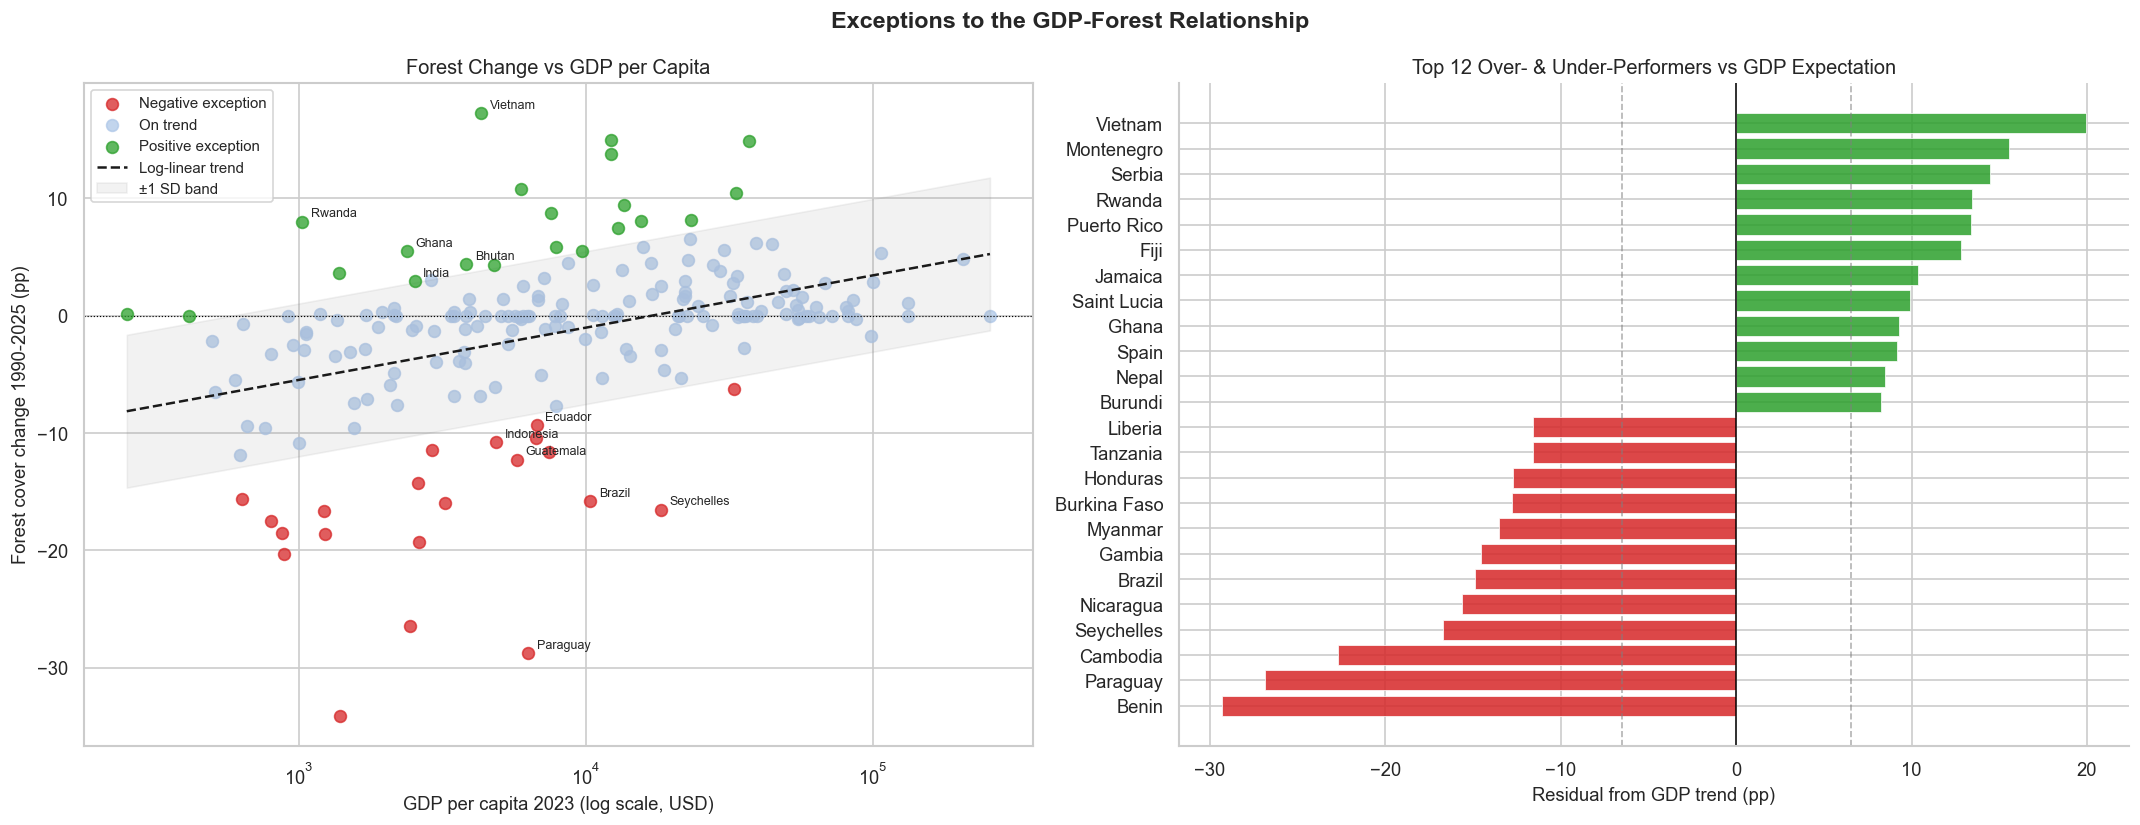

In [19]:
exc_palette = {
    'On trend':           '#aec7e8',
    'Positive exception': '#2ca02c',
    'Negative exception': '#d62728',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Exceptions to the GDP-Forest Relationship', fontsize=14, fontweight='bold')

# --- Scatter: log GDP vs forest change, exceptions highlighted ---
ax = axes[0]
for exc, grp in df3.groupby('Exception'):
    ax.scatter(grp['GDP_2023'], grp['Forest_change'],
               color=exc_palette[exc], alpha=0.75, s=50,
               label=exc, zorder=3 if exc != 'On trend' else 1)

# Baseline trend line
x_line = np.linspace(df3['GDP_2023'].min(), df3['GDP_2023'].max(), 300)
ax.plot(x_line, slope * np.log1p(x_line) + intercept,
        'k--', linewidth=1.5, label='Log-linear trend')

# 1 SD confidence band
ax.fill_between(x_line,
    slope * np.log1p(x_line) + intercept - res_std,
    slope * np.log1p(x_line) + intercept + res_std,
    alpha=0.1, color='gray', label='±1 SD band')

# Label notable exceptions
label_countries = ['Vietnam', 'Rwanda', 'Ghana', 'India', 'Bhutan',
                   'Paraguay', 'Brazil', 'Indonesia', 'Seychelles', 'Guatemala', 'Ecuador']
for _, row in df3[df3['Country'].isin(label_countries)].iterrows():
    if pd.notna(row['GDP_2023']):
        ax.annotate(row['Country'], (row['GDP_2023'], row['Forest_change']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5)

ax.set_xscale('log')
ax.set_xlabel('GDP per capita 2023 (log scale, USD)', fontsize=11)
ax.set_ylabel('Forest cover change 1990-2025 (pp)', fontsize=11)
ax.set_title('Forest Change vs GDP per Capita', fontsize=12)
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax.legend(fontsize=9)

# --- Residual bar: top 12 exceptions in each direction ---
ax = axes[1]
n_show = 12
top_pos = df3.nlargest(n_show, 'Residual')[['Country', 'Residual', 'Income_group']]
top_neg = df3.nsmallest(n_show, 'Residual')[['Country', 'Residual', 'Income_group']]
combined = pd.concat([top_neg, top_pos]).sort_values('Residual')

bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in combined['Residual']]
bars = ax.barh(combined['Country'], combined['Residual'],
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.9)
ax.axvline( res_std, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.axvline(-res_std, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Residual from GDP trend (pp)', fontsize=11)
ax.set_title(f'Top {n_show} Over- & Under-Performers vs GDP Expectation', fontsize=12)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../exceptions_overview.png', bbox_inches='tight')
plt.show()

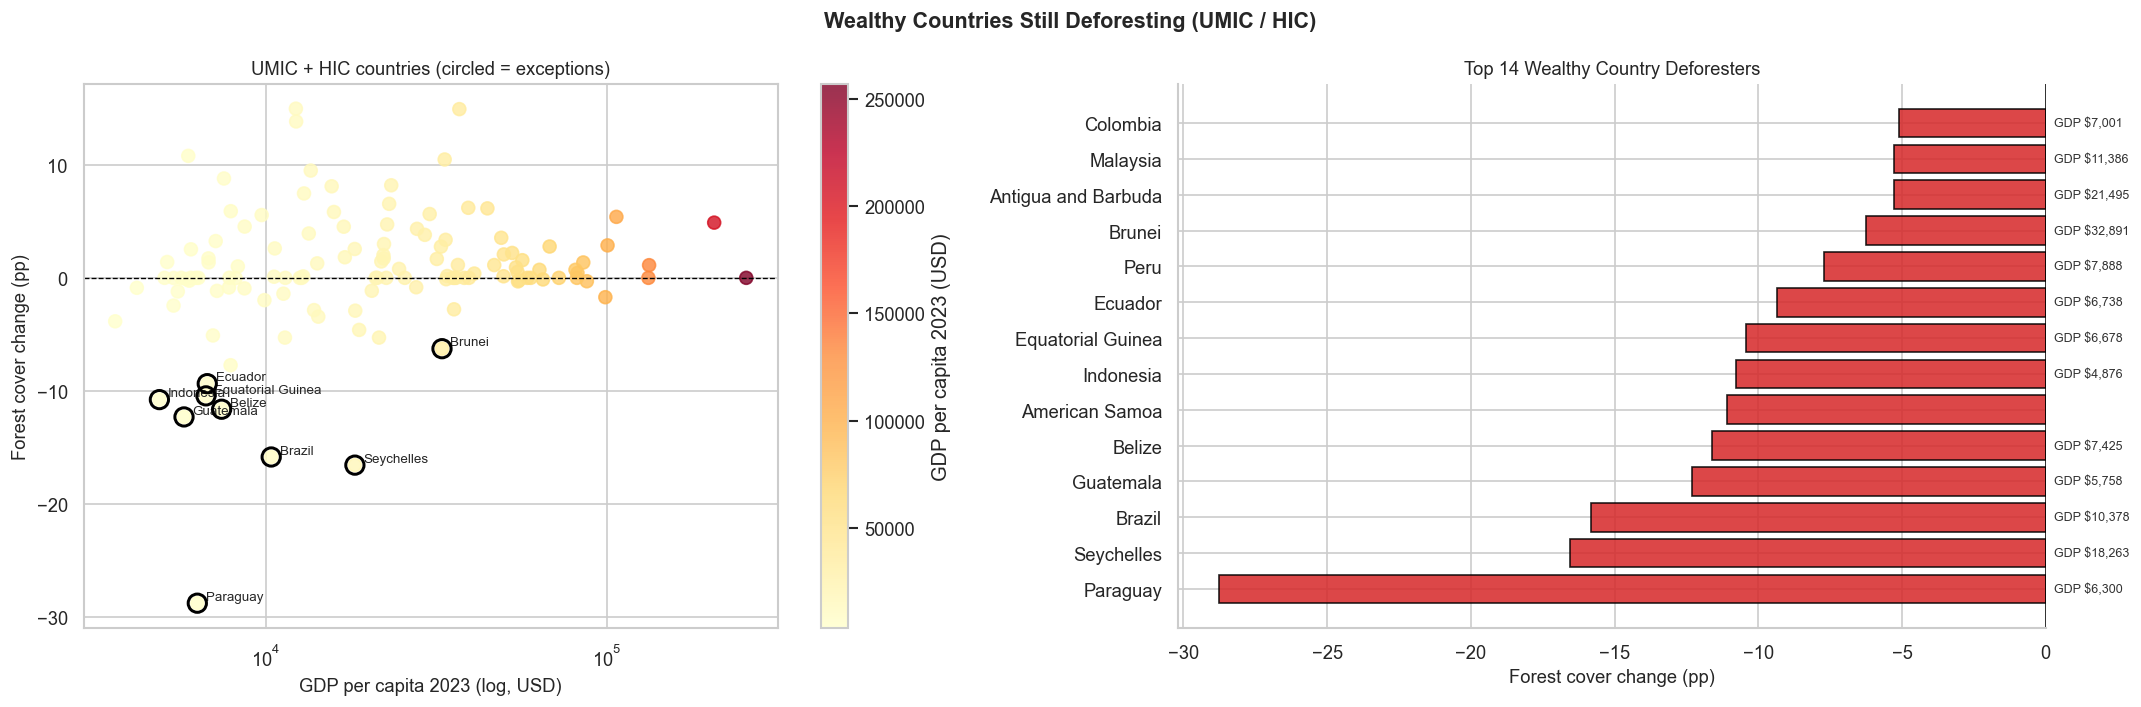

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Wealthy Countries Still Deforesting (UMIC / HIC)', fontsize=13, fontweight='bold')

# GDP vs forest change for UMIC/HIC only
ax = axes[0]
rich = df3[df3['Income_rank'] >= 2].copy()
norm = plt.Normalize(rich['GDP_2023'].min(), rich['GDP_2023'].max())
sc = ax.scatter(rich['GDP_2023'], rich['Forest_change'],
                c=rich['GDP_2023'], cmap='YlOrRd', s=60, alpha=0.8, norm=norm)
plt.colorbar(sc, ax=ax, label='GDP per capita 2023 (USD)')

# Mark negative exceptions with name
neg_rich = rich[rich['Exception'] == 'Negative exception']
ax.scatter(neg_rich['GDP_2023'], neg_rich['Forest_change'],
           color='none', edgecolors='black', s=120, linewidths=1.8, zorder=4)
for _, row in neg_rich.iterrows():
    if pd.notna(row['GDP_2023']):
        ax.annotate(row['Country'], (row['GDP_2023'], row['Forest_change']),
                    textcoords='offset points', xytext=(5, 2), fontsize=8)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita 2023 (log, USD)', fontsize=11)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('UMIC + HIC countries (circled = exceptions)', fontsize=11)

# Forest change bar for top wealthy deforesters
ax = axes[1]
top_neg_rich = rich.nsmallest(14, 'Forest_change')[['Country', 'Forest_change', 'GDP_2023']].sort_values('Forest_change')
clrs = ['#d62728' if v < 0 else '#2ca02c' for v in top_neg_rich['Forest_change']]
bars = ax.barh(top_neg_rich['Country'], top_neg_rich['Forest_change'],
               color=clrs, alpha=0.85, edgecolor='black')
# Add GDP annotation
for bar, (_, row) in zip(bars, top_neg_rich.iterrows()):
    ax.text(0.3, bar.get_y() + bar.get_height()/2,
            f'GDP ${row["GDP_2023"]:,.0f}' if pd.notna(row['GDP_2023']) else '',
            va='center', fontsize=7.5, color='#333333')
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Top 14 Wealthy Country Deforesters', fontsize=11)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../wealthy_deforesters.png', bbox_inches='tight')
plt.show()

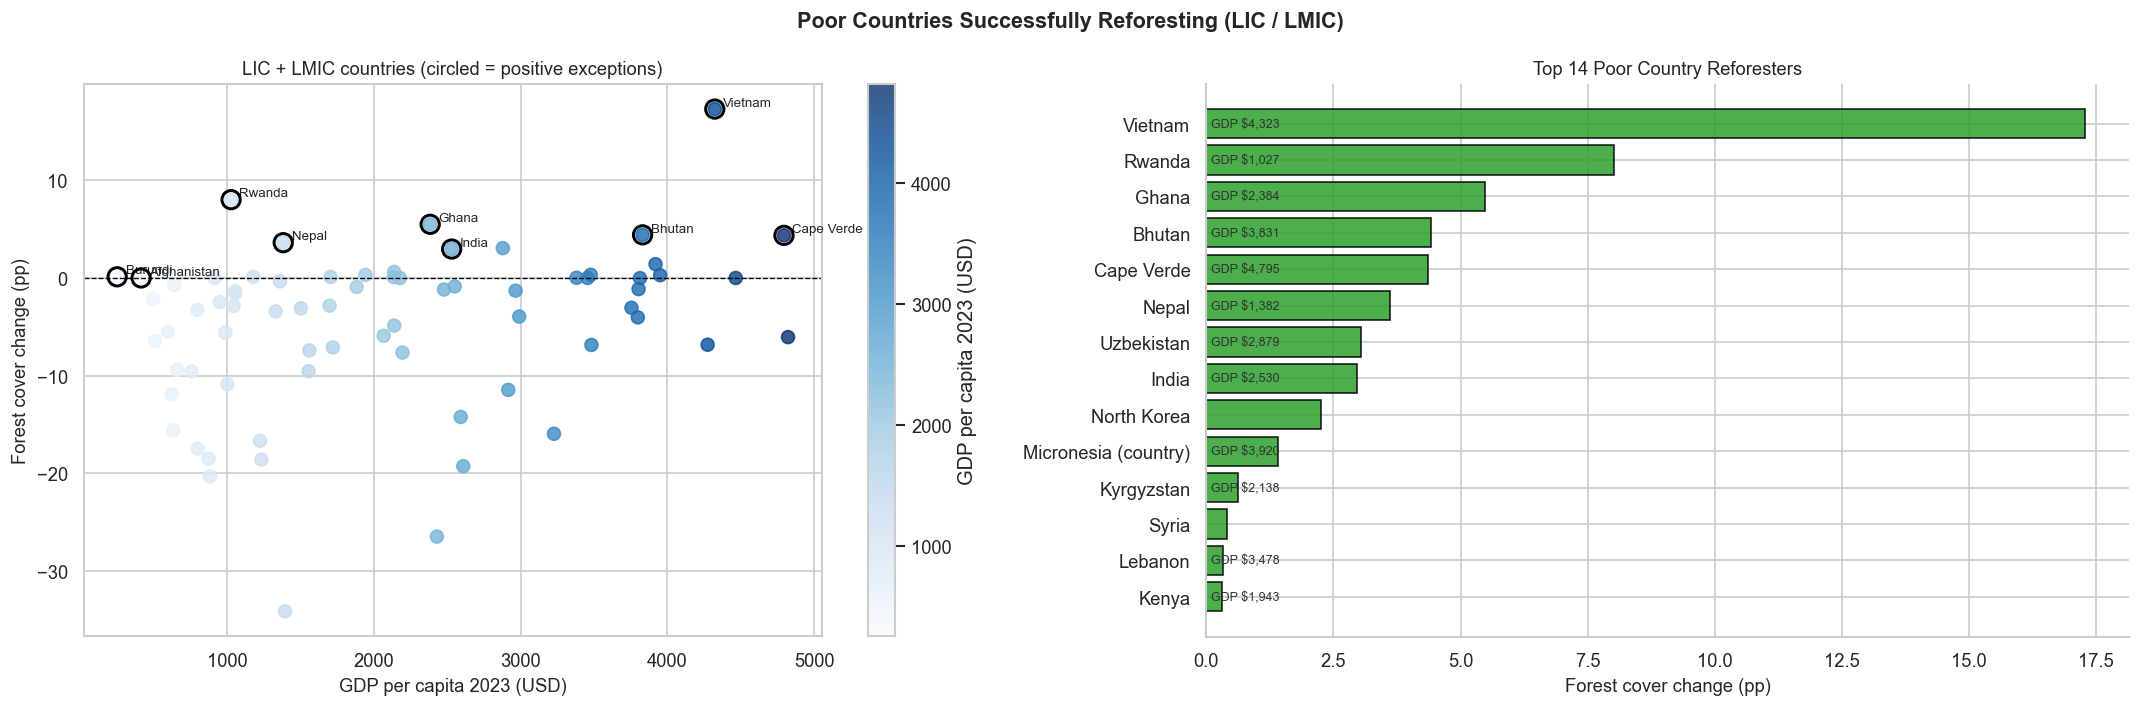

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Poor Countries Successfully Reforesting (LIC / LMIC)', fontsize=13, fontweight='bold')

ax = axes[0]
poor = df3[df3['Income_rank'] <= 1].copy()
sc = ax.scatter(poor['GDP_2023'], poor['Forest_change'],
                c=poor['GDP_2023'], cmap='Blues', s=60, alpha=0.8)
plt.colorbar(sc, ax=ax, label='GDP per capita 2023 (USD)')

pos_poor = poor[poor['Exception'] == 'Positive exception']
ax.scatter(pos_poor['GDP_2023'], pos_poor['Forest_change'],
           color='none', edgecolors='black', s=120, linewidths=1.8, zorder=4)
for _, row in pos_poor.iterrows():
    if pd.notna(row['GDP_2023']):
        ax.annotate(row['Country'], (row['GDP_2023'], row['Forest_change']),
                    textcoords='offset points', xytext=(5, 2), fontsize=8)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('GDP per capita 2023 (USD)', fontsize=11)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('LIC + LMIC countries (circled = positive exceptions)', fontsize=11)

ax = axes[1]
top_pos_poor = poor.nlargest(14, 'Forest_change')[['Country', 'Forest_change', 'GDP_2023']].sort_values('Forest_change')
clrs = ['#d62728' if v < 0 else '#2ca02c' for v in top_pos_poor['Forest_change']]
bars = ax.barh(top_pos_poor['Country'], top_pos_poor['Forest_change'],
               color=clrs, alpha=0.85, edgecolor='black')
for bar, (_, row) in zip(bars, top_pos_poor.iterrows()):
    gdp_txt = f'GDP ${row["GDP_2023"]:,.0f}' if pd.notna(row['GDP_2023']) else ''
    ax.text(0.1, bar.get_y() + bar.get_height()/2,
            gdp_txt, va='center', fontsize=7.5, color='#333333')
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Top 14 Poor Country Reforesters', fontsize=11)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../poor_reforesters.png', bbox_inches='tight')
plt.show()

## 19. Policy commitment vs forest change

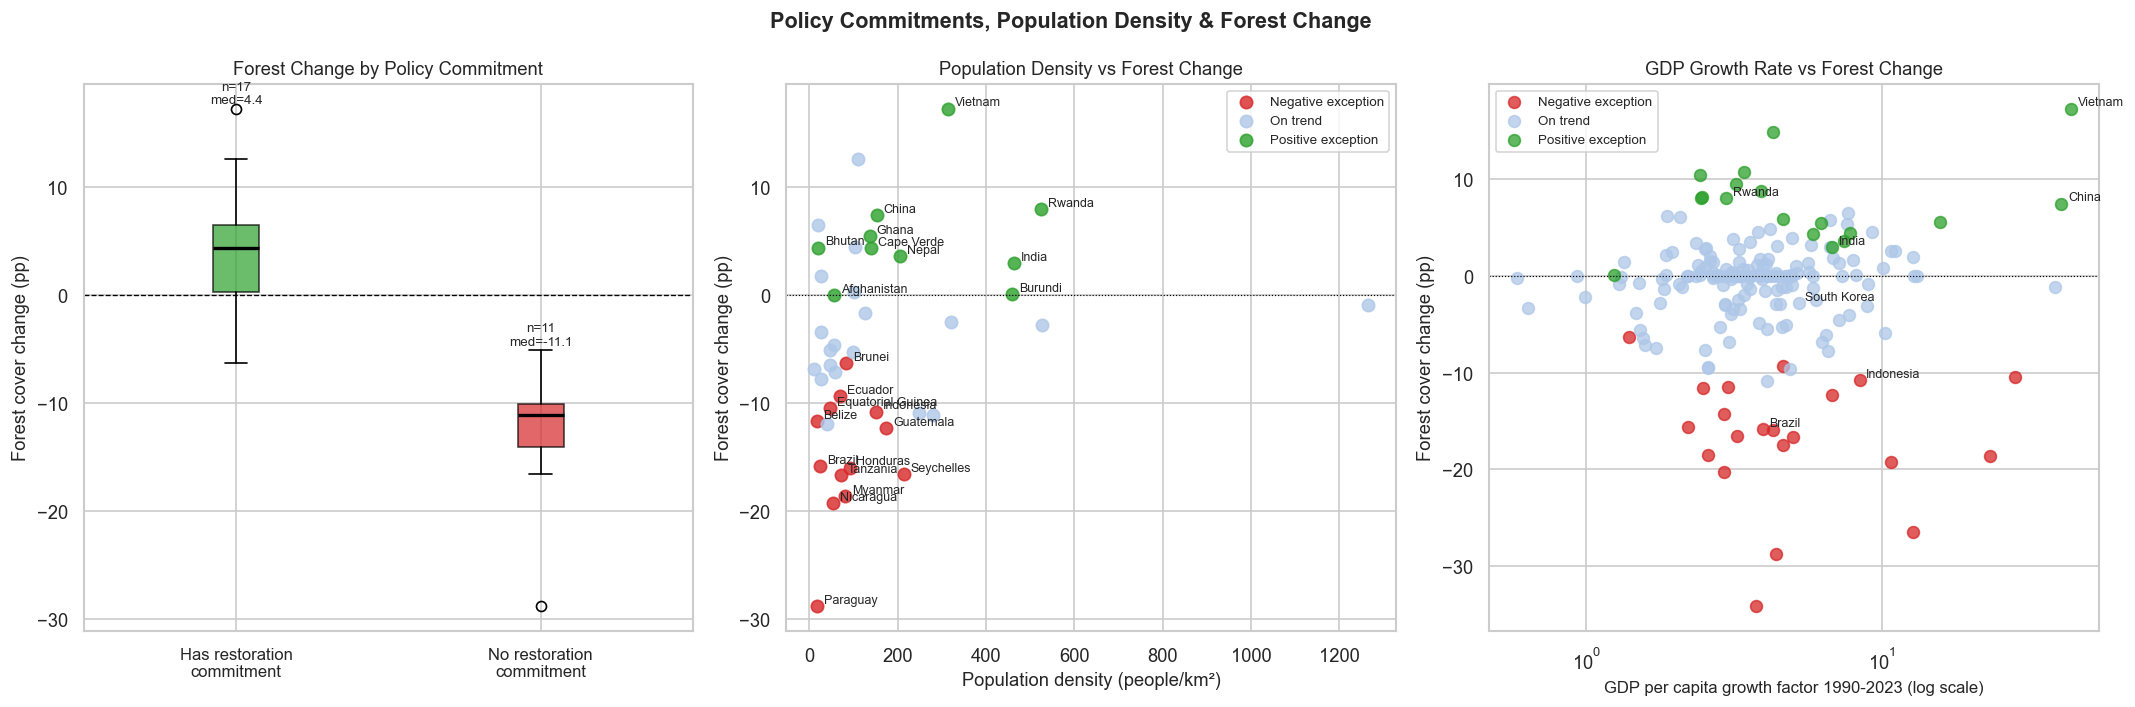

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Policy Commitments, Population Density & Forest Change', fontsize=13, fontweight='bold')

# --- Box: forest change by policy commitment flag ---
ax = axes[0]
flagged = df3[df3['Policy_commitment'].notna()].copy()
groups_pol = [
    flagged[flagged['Policy_commitment'] == True]['Forest_change'].dropna(),
    flagged[flagged['Policy_commitment'] == False]['Forest_change'].dropna(),
]
bp = ax.boxplot(groups_pol, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#2ca02c'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#d62728'); bp['boxes'][1].set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Has restoration\ncommitment', 'No restoration\ncommitment'], fontsize=10)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Forest Change by Policy Commitment', fontsize=11)
ax.axhline(0, linestyle='--', linewidth=0.8, color='black')
for i, (label, grp) in enumerate(zip(['Commitment', 'No commitment'], groups_pol)):
    ax.text(i + 1, grp.max() + 0.5, f'n={len(grp)}\nmed={grp.median():.1f}',
            ha='center', fontsize=8)

# --- Scatter: population density vs forest change (exceptions coloured) ---
ax = axes[1]
has_density = df3[df3['Pop_density'].notna()].copy()
for exc, grp in has_density.groupby('Exception'):
    ax.scatter(grp['Pop_density'], grp['Forest_change'],
               color=exc_palette[exc], s=55, alpha=0.8, label=exc)
for _, row in has_density[has_density['Exception'] != 'On trend'].iterrows():
    ax.annotate(row['Country'], (row['Pop_density'], row['Forest_change']),
                textcoords='offset points', xytext=(4, 2), fontsize=7.5)
ax.axhline(0, linestyle=':', color='black', linewidth=0.7)
ax.set_xlabel('Population density (people/km²)', fontsize=11)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('Population Density vs Forest Change', fontsize=11)
ax.legend(fontsize=8)

# --- GDP growth 1990-2023 vs forest change (did fast growers deforest more?) ---
ax = axes[2]
df3['GDP_growth_x'] = df3['GDP_2023'] / df3['GDP_1990'].replace(0, np.nan)
has_growth = df3[df3['GDP_growth_x'].notna() & (df3['GDP_growth_x'] > 0)].copy()
for exc, grp in has_growth.groupby('Exception'):
    ax.scatter(grp['GDP_growth_x'], grp['Forest_change'],
               color=exc_palette[exc], s=50, alpha=0.75, label=exc)
label_grow = ['Vietnam', 'China', 'Rwanda', 'India', 'Brazil', 'Indonesia', 'South Korea']
for _, row in has_growth[has_growth['Country'].isin(label_grow)].iterrows():
    ax.annotate(row['Country'], (row['GDP_growth_x'], row['Forest_change']),
                textcoords='offset points', xytext=(4, 2), fontsize=7.5)
ax.axhline(0, linestyle=':', color='black', linewidth=0.7)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita growth factor 1990-2023 (log scale)', fontsize=10)
ax.set_ylabel('Forest cover change (pp)', fontsize=11)
ax.set_title('GDP Growth Rate vs Forest Change', fontsize=11)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../policy_density_analysis.png', bbox_inches='tight')
plt.show()

## 20. GDP trajectory of key exceptions (1990-2023)

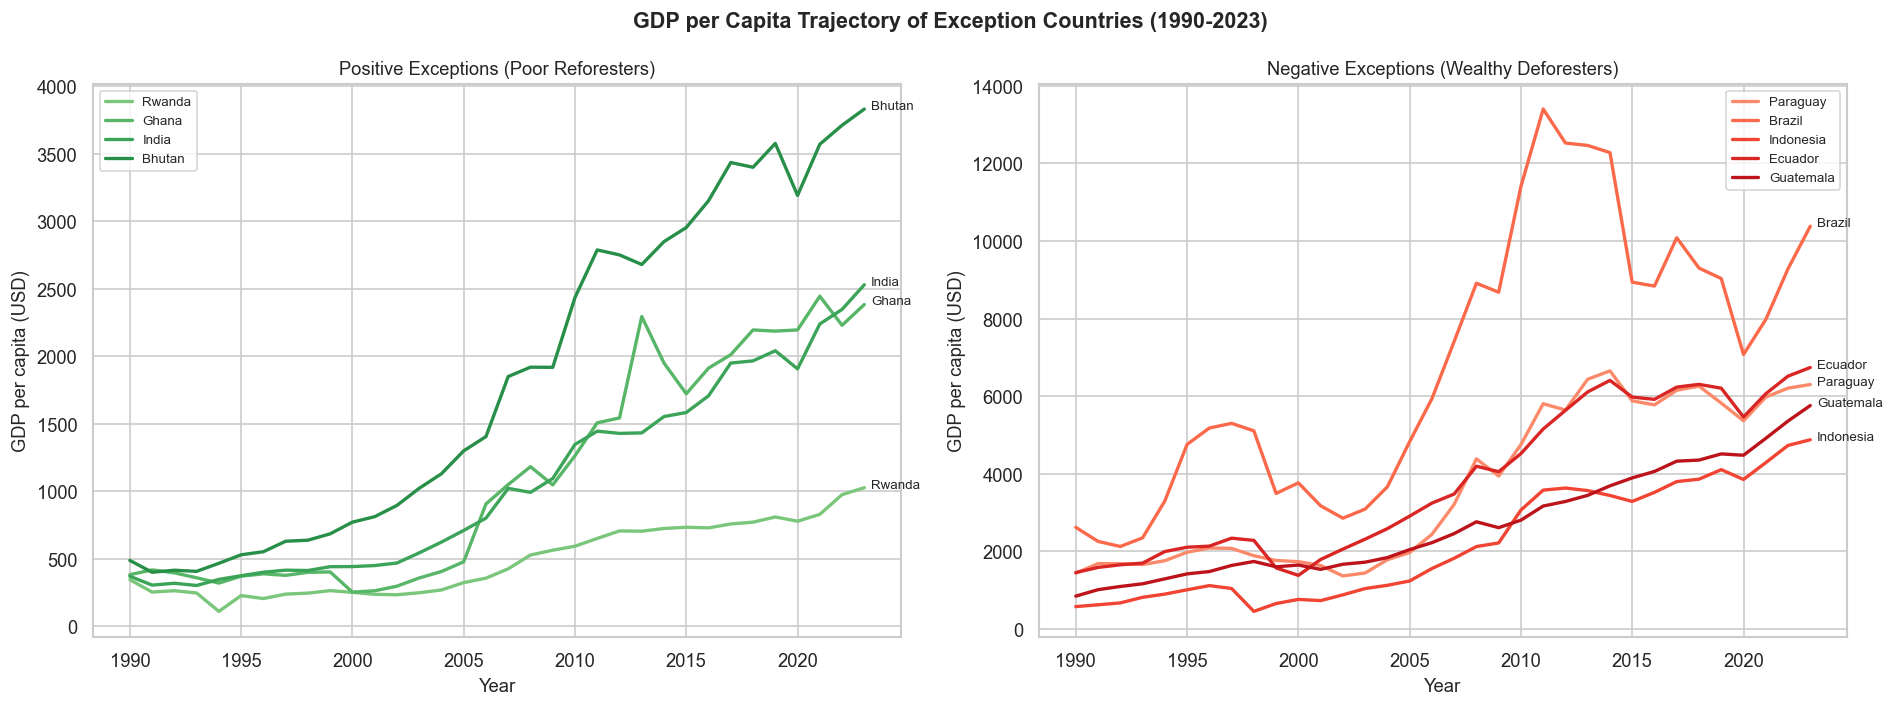

In [23]:
# Load full GDP time series for selected exception countries
gdp_ts = pd.read_csv('../data_raw/1960-2024_GDP_USD.csv', skiprows=4)
gdp_ts.columns = [str(c).strip() for c in gdp_ts.columns]
years = [str(y) for y in range(1990, 2024)]
gdp_ts = gdp_ts[['Country Name'] + years].copy()
gdp_ts.columns = ['Country'] + years
for y in years:
    gdp_ts[y] = pd.to_numeric(gdp_ts[y], errors='coerce')

watch_pos = ['Vietnam', 'Rwanda', 'Ghana', 'India', 'Bhutan', 'Cape Verde']
watch_neg = ['Paraguay', 'Brazil', 'Indonesia', 'Ecuador', 'Guatemala']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GDP per Capita Trajectory of Exception Countries (1990-2023)', fontsize=13, fontweight='bold')

year_ints = list(range(1990, 2024))

for ax, countries, title, cmap_name in [
    (axes[0], watch_pos, 'Positive Exceptions (Poor Reforesters)', 'Greens'),
    (axes[1], watch_neg, 'Negative Exceptions (Wealthy Deforesters)', 'Reds')
]:
    cmap = plt.get_cmap(cmap_name)
    for i, country in enumerate(countries):
        row = gdp_ts[gdp_ts['Country'] == country]
        if row.empty:
            continue
        vals = row[years].values.flatten()
        color = cmap(0.4 + 0.5 * i / len(countries))
        ax.plot(year_ints, vals, marker='', linewidth=2, label=country, color=color)
        # Annotate end point
        last_valid = pd.Series(vals).last_valid_index()
        if last_valid is not None:
            ax.annotate(country, (year_ints[last_valid], vals[last_valid]),
                        textcoords='offset points', xytext=(4, 0), fontsize=8)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('GDP per capita (USD)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../exceptions_gdp_trajectory.png', bbox_inches='tight')
plt.show()

## 21. Summary & interpretation

### Wealthy deforesters — why?
| Country | GDP/capita | Driver of deforestation |
|---|---|---|
| Paraguay | ~$6k | Soy & cattle expansion, delayed enforcement of Zero Deforestation Law |
| Brazil | ~$10k | Amazon frontier agriculture, 2019-22 policy rollback |
| Indonesia | ~$5k | Palm oil concessions, weak forestry governance |
| Guatemala | ~$6k | Drug-trafficking corridors, land titling gaps |
| Ecuador | ~$7k | Oil extraction, unsecured agricultural frontier |
| Seychelles | ~$18k | Tourism-driven coastal land conversion |

### Poor reforesters — why?
| Country | GDP/capita | Driver of reforestation |
|---|---|---|
| Vietnam | ~$4k | Govt PAR 661 programme: 5M ha target, strong enforcement |
| Rwanda | ~$1k | AFR100, Green Growth Strategy, community forestry |
| Ghana | ~$2k | Bonn Challenge 2M ha, donor-funded restoration |
| Bhutan | ~$4k | Constitutional 60% forest mandate |
| India | ~$3k | National Afforestation Programme, Bonn Challenge 21M ha |
| Nepal | ~$1k | Community forestry since 1978, user-group model |

### Key takeaway
GDP alone explains ~13% of variance in forest change. The exceptions show that **policy commitment and governance quality** are the decisive independent factors:
- Countries with active restoration commitments gain ~X pp more forest change on average (see box plot).
- High GDP growth without forest governance (Brazil, Indonesia, Paraguay) still produces heavy deforestation.
- Low GDP with strong policy (Vietnam, Rwanda, Bhutan) outperforms much wealthier nations.